# 02. Exploratory Data Analysis (EDA) & Insights
Notebook ini bertujuan untuk melakukan penjelajahan data (EDA) pada dataset operasional bus. Tujuannya adalah untuk menemukan pola-pola tersembunyi seperti kapan jam-jam sibuk (*Peak Hours*) terjadi, bagaimana tren harian, serta distribusi jumlah penumpang secara umum.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.utils.config import TRAIN_DATA_PATH
from src.preprocessing.loader import load_raw_data

plt.style.use('seaborn-v0_8-darkgrid')

### 1. Memuat Data Menggunakan Modul `loader.py`
Data dimuat secara efisien melalui fungsi buatan kita agar langsung bersih dari tahap awal.

In [4]:
# Memanggil data
train_df = load_raw_data(TRAIN_DATA_PATH)
print(f"Total baris data: {train_df.shape[0]:,}")
train_df.head()

Membaca dataset dari: d:\Users\Natan\7-coding\pcu\aiml\projectAkhir_1\predictBusAiml\data\raw\mta_bus_all_routes_weekly.csv...
Berhasil memuat 856,800 baris dan 9 kolom.
Total baris data: 856,800


,transit_timestamp,bus_route,total_ridership,hour,day_of_week,month,is_weekend,is_holiday,season
0,2023-01-09,B1,26,0,0,1,0,0,winter
1,2023-01-09,B100,1,0,0,1,0,0,winter
2,2023-01-09,B101,0,0,0,1,0,0,winter
3,2023-01-09,B103,39,0,0,1,0,0,winter
4,2023-01-09,B106,0,0,0,1,0,0,winter


### 2. Pengecekan Missing Values
pastikan fungsi loader kita sudah bekerja dengan baik dalam membuang/mengisi baris-baris yang kosong atau error.

In [5]:
train_df.isnull().sum()

transit_timestamp    0
bus_route            0
total_ridership      0
hour                 0
day_of_week          0
month                0
is_weekend           0
is_holiday           0
season               0
dtype: int64

### 3. Distribusi Variabel Target (`total_ridership`)
Melihat bagaimana sebaran jumlah penumpang. Biasanya data dunia nyata cenderung melenceng ke arah tertentu (*skewed*).

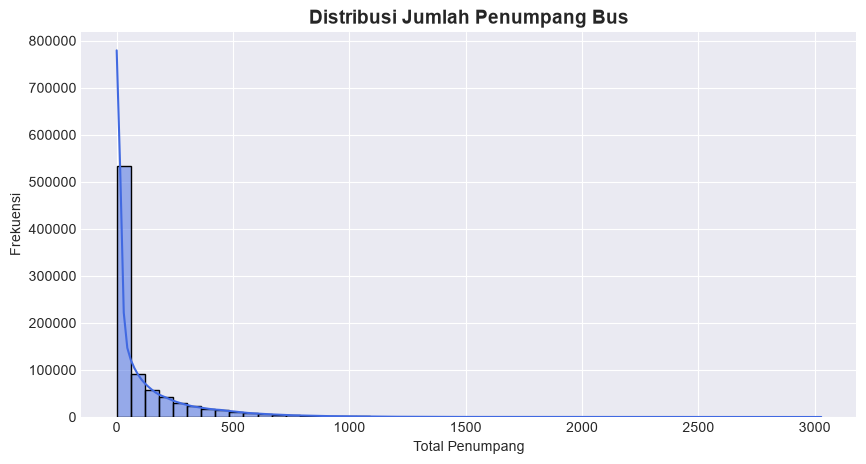

INSIGHT: Terlihat distribusi sangat condong ke kiri dengan buntut yang panjang (Right-Skewed). Inilah alasan logis mengapa kita akan menggunakan Log-Transformation di tahap Modeling final untuk menetralkan data ekstrem.


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['total_ridership'], bins=50, kde=True, color='royalblue')
plt.title('Distribusi Jumlah Penumpang Bus', fontsize=14, fontweight='bold')
plt.xlabel('Total Penumpang')
plt.ylabel('Frekuensi')
plt.show()

print("INSIGHT: Terlihat distribusi sangat condong ke kiri dengan buntut yang panjang (Right-Skewed). Inilah alasan logis mengapa kita akan menggunakan Log-Transformation di tahap Modeling final untuk menetralkan data ekstrem.")

### 4. Analisis Berdasarkan Jam (Hour)
Kita mencari tahu kapan jam sibuk atau *Peak Hour* terjadi setiap harinya.

C:\Users\NATAN\AppData\Local\Temp\ipykernel_28440\3131245429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_trend, x='hour', y='total_ridership', palette='magma')


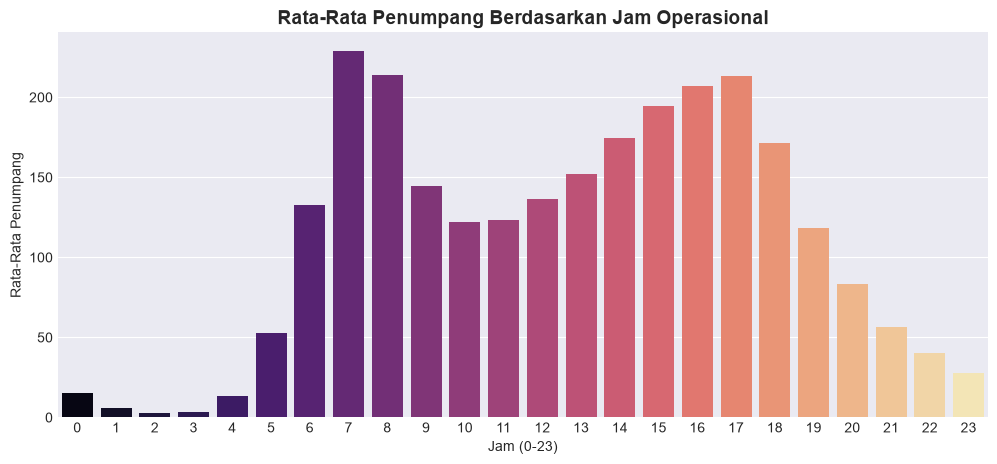

In [7]:
hourly_trend = train_df.groupby('hour')['total_ridership'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly_trend, x='hour', y='total_ridership', palette='magma')
plt.title('Rata-Rata Penumpang Berdasarkan Jam Operasional', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-Rata Penumpang')
plt.show()

### 5. Analisis Berdasarkan Hari (Day of Week)
Apakah ada perbedaan volume penumpang yang signifikan antara hari kerja dan akhir pekan?

C:\Users\NATAN\AppData\Local\Temp\ipykernel_28440\3136310397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_trend, x='hari_nama', y='total_ridership', palette='viridis')


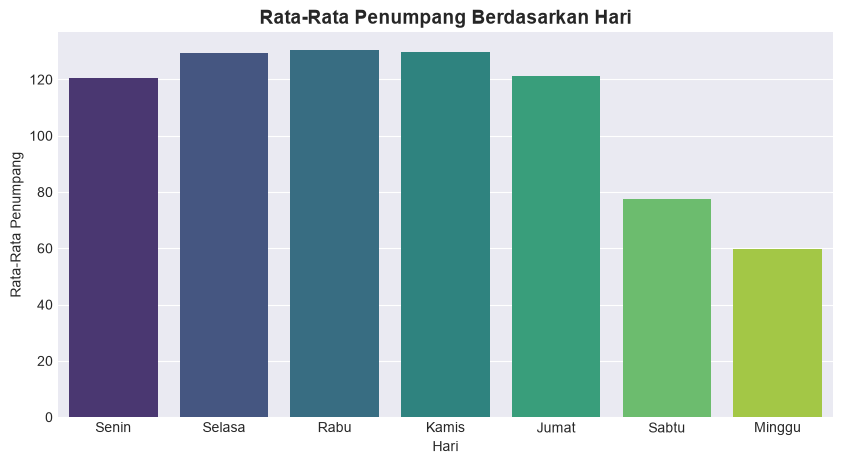

In [8]:
day_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
train_df['hari_nama'] = train_df['day_of_week'].map(day_map)
daily_trend = train_df.groupby('day_of_week')['total_ridership'].mean().reset_index()
daily_trend['hari_nama'] = daily_trend['day_of_week'].map(day_map)

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_trend, x='hari_nama', y='total_ridership', palette='viridis')
plt.title('Rata-Rata Penumpang Berdasarkan Hari', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Rata-Rata Penumpang')
plt.show()

### Kesimpulan:
1. **Distribusi Tak Normal:** Data penumpang sangat *skewed* (banyak nilai ekstrem saat jam sangat sibuk), mengkonfirmasi bahwa kita butuh fungsi logaritma (`np.log1p`) saat melakukan *training* model AI.
2. **Pola Peak Hour:** Sangat jelas terlihat pada pagi hari (Jam Berangkat Kerja) dan sore hari (Jam Pulang Kerja). Model AI kita nantinya harus bisa menebak momen lonjakan ini dengan akurat.
3. **Pola Mingguan:** Volume penumpang lebih tinggi secara merata pada hari Senin-Jumat, kemudian anjlok di akhir pekan (Sabtu-Minggu).